


# ============================================================
# MODEL / EXPERIMENT CONFIGURATION
Final 15 min wavelet Model
# ============================================================
resample_freq = "15min"

train_ratio = 0.70

val_ratio = 0.15

test_ratio = 0.15

target_col = "scd41_co2"

history_days = 60 days

forecast_hours = 15 min

batch_size = 64

num_epochs = 15

d_model=32

nhead=4,

num_layers=1,

dim_feedforward=64,

dropout=0.2

lr=0.0003

J=4

Q=16




In [1]:
USE_WAVELET = True

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from kymatio.numpy import Scattering1D


In [3]:
df = pd.read_csv("../../data/indoorAir2.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Sort by station and time
df = df.sort_values(by='timestamp')

print(df.shape)
df.head()

(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Remove Station id 6
df = df[df["station_id"] != 6].copy()

feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "station_id",
    ]
].copy()

resample_freq = "15min"

value_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
]

feature_df["timestamp"] = pd.to_datetime(feature_df["timestamp"])

feature_df = (
    feature_df
    .sort_values(["station_id", "timestamp"])
    .set_index("timestamp")
    .groupby("station_id")[value_cols]
    .resample(resample_freq)
    .mean()
    .reset_index()
)

feature_df[value_cols] = (
    feature_df
    .groupby("station_id")[value_cols]
    .transform(lambda x: x.interpolate(method="linear").ffill().bfill())
)

feature_df["hour"] = feature_df["timestamp"].dt.hour + feature_df["timestamp"].dt.minute / 60
feature_df["dayofweek"] = feature_df["timestamp"].dt.dayofweek

feature_df["hour_sin"] = np.sin(2 * np.pi * feature_df["hour"] / 24)
feature_df["hour_cos"] = np.cos(2 * np.pi * feature_df["hour"] / 24)

feature_df["dayofweek_sin"] = np.sin(2 * np.pi * feature_df["dayofweek"] / 7)
feature_df["dayofweek_cos"] = np.cos(2 * np.pi * feature_df["dayofweek"] / 7)

feature_df["is_weekend"] = feature_df["dayofweek"].isin([5, 6]).astype(int)

feature_df = feature_df.drop(columns=["hour", "dayofweek"])

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()

(186889, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [5]:
feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

feature_df["next_timestamp"] = (
    feature_df
    .groupby("station_id")["timestamp"]
    .shift(-1)
)

feature_df["next_gap"] = feature_df["next_timestamp"] - feature_df["timestamp"]

feature_df = feature_df[
    feature_df["next_gap"].between(
        pd.Timedelta(minutes=13),
        pd.Timedelta(minutes=17)
    )
].copy()

feature_df = feature_df.drop(columns=["next_timestamp", "next_gap"])

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()

(186884, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [6]:
cols_to_fill = ["bme688_gas_resistance", "bme688_pressure"]

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .transform(lambda x: x.interpolate(method="linear"))
)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .ffill()
    .bfill()
)

print(feature_df.shape)
feature_df.head()

(186884, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [7]:
numeric_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2"
]

outlier_bounds = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_bounds[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count_before": ((feature_df[col] < lower) | (feature_df[col] > upper)).sum(),
        "outlier_percent_before": ((feature_df[col] < lower) | (feature_df[col] > upper)).mean() * 100
    }

    feature_df[col] = feature_df[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_bounds).T
print(outlier_df)
print(feature_df.shape)
feature_df.head()

                        lower_bound   upper_bound  outlier_count_before  \
ens160_aqi            -5.000000e-01  3.500000e+00                2125.0   
ens160_tvoc           -9.768571e+01  2.889048e+02               18971.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07                   0.0   
bme688_pressure        9.849031e+01  1.018882e+02                7020.0   
scd41_temperature      1.971432e+01  2.910343e+01                3303.0   
scd41_humidity         8.847241e+00  6.352849e+01                  86.0   
scd41_co2              2.501637e+02  7.448383e+02               18972.0   

                       outlier_percent_before  
ens160_aqi                           1.137069  
ens160_tvoc                         10.151217  
bme688_gas_resistance                0.000000  
bme688_pressure                      3.756341  
scd41_temperature                    1.767407  
scd41_humidity                       0.046018  
scd41_co2                           10.151752  
(186884, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [8]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((feature_df[col] < lower) | (feature_df[col] > upper)).sum()

    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": (outlier_count / len(feature_df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

                        lower_bound   upper_bound  outlier_count  \
ens160_aqi            -5.000000e-01  3.500000e+00            0.0   
ens160_tvoc           -9.768571e+01  2.889048e+02            0.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07            0.0   
bme688_pressure        9.849031e+01  1.018882e+02            0.0   
scd41_temperature      1.971432e+01  2.910343e+01            0.0   
scd41_humidity         8.847241e+00  6.352849e+01            0.0   
scd41_co2              2.501637e+02  7.448383e+02            0.0   

                       outlier_percent  
ens160_aqi                         0.0  
ens160_tvoc                        0.0  
bme688_gas_resistance              0.0  
bme688_pressure                    0.0  
scd41_temperature                  0.0  
scd41_humidity                     0.0  
scd41_co2                          0.0  


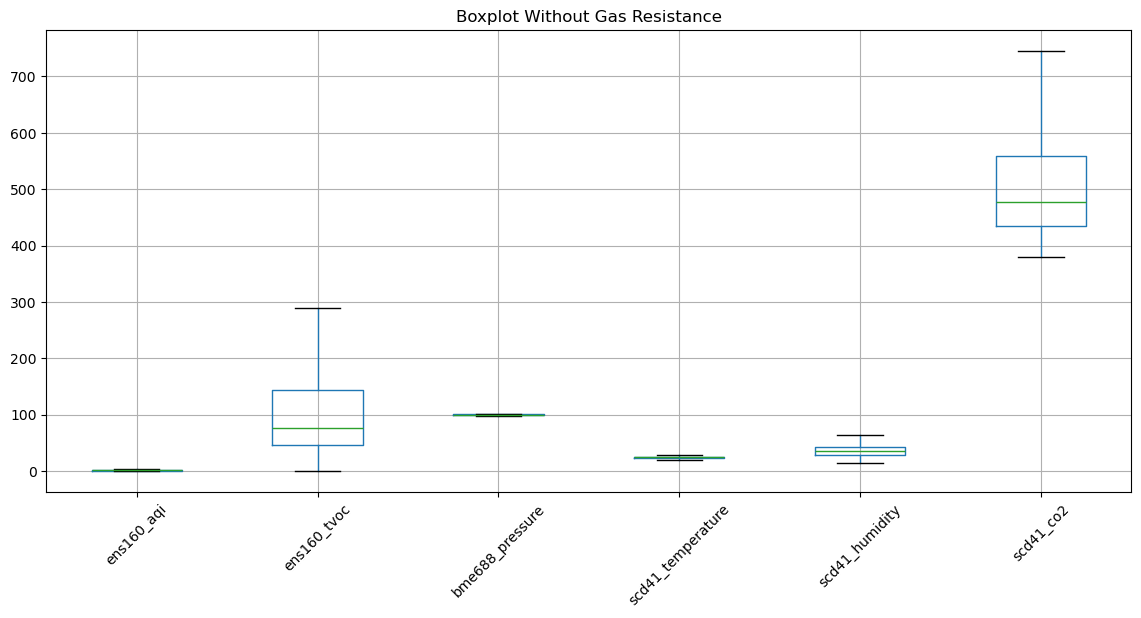

In [9]:
plot_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2"
]

feature_df[plot_cols].boxplot(figsize=(14, 6), rot=45)
plt.title("Boxplot Without Gas Resistance")
plt.show()

In [10]:
# ==========================================
# Step 8 - Time-Based Split
# ==========================================

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

def split_station_data(station_data):
    station_data = station_data.sort_values("timestamp")
    n_rows = len(station_data)
    train_end = int(n_rows * train_ratio)
    val_end = train_end + int(n_rows * val_ratio)

    return (
        station_data.iloc[:train_end],
        station_data.iloc[train_end:val_end],
        station_data.iloc[val_end:],
    )

train_parts = []
val_parts = []
test_parts = []

for station_id, station_data in feature_df.groupby("station_id", sort=True):
    station_train, station_val, station_test = split_station_data(station_data)
    train_parts.append(station_train)
    val_parts.append(station_val)
    test_parts.append(station_test)

train_df = pd.concat(train_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
val_df = pd.concat(val_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
test_df = pd.concat(test_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)

total_rows = len(feature_df)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Train percentage:", len(train_df) / total_rows * 100)
print("Val percentage:", len(val_df) / total_rows * 100)
print("Test percentage:", len(test_df) / total_rows * 100)

split_counts = pd.concat(
    [
        train_df.groupby("station_id").size().rename("train"),
        val_df.groupby("station_id").size().rename("val"),
        test_df.groupby("station_id").size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print("\nRows per station:")
print(split_counts)

Train shape: (130816, 14)
Val shape: (28031, 14)
Test shape: (28037, 14)
Train percentage: 69.99850174439759
Val percentage: 14.999143853941483
Test percentage: 15.002354401660922

Rows per station:
            train   val  test
station_id                   
1           35269  7557  7559
2           13566  2907  2908
3           30913  6624  6625
4           30627  6563  6564
5           20441  4380  4381


In [11]:
target_col = "scd41_co2"

feature_cols = [
    col for col in feature_df.columns
    if col not in ["timestamp"]
]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
val_df_scaled[feature_cols] = x_scaler.transform(val_df[feature_cols])
test_df_scaled[feature_cols] = x_scaler.transform(test_df[feature_cols])

train_df_scaled[[target_col]] = y_scaler.fit_transform(train_df[[target_col]])
val_df_scaled[[target_col]] = y_scaler.transform(val_df[[target_col]])
test_df_scaled[[target_col]] = y_scaler.transform(test_df[[target_col]])

print("Input features:", feature_cols)
print("Past CO2 included:", target_col in feature_cols)
print("Scaled X train min/max:", train_df_scaled[feature_cols].min().min(), train_df_scaled[feature_cols].max().max())
print("Scaled y train min/max:", train_df_scaled[target_col].min(), train_df_scaled[target_col].max())

Input features: ['station_id', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend']
Past CO2 included: True
Scaled X train min/max: 0.0 1.0000000000000002
Scaled y train min/max: 0.0 1.0000000000000002


In [12]:
input_size = 60   # 60 rows * 15 min = past 15 hours
target_col = "scd41_co2"

feature_cols = [
    col for col in feature_df.columns
    if col != "timestamp"
]

def create_windows(data, feature_cols, target_col):
    X_windows = []
    y_windows = []

    data = data.sort_values(["station_id", "timestamp"])

    for station_id, station_data in data.groupby("station_id"):
        X = station_data[feature_cols].values.astype("float32")
        y = station_data[target_col].values.astype("float32")

        # X uses previous 60 timestamps, y uses next timestamp
        # Since data is 15-min sampled, y[i] = CO2 15 min ahead
        for i in range(input_size, len(station_data)):
            X_windows.append(X[i - input_size:i])
            y_windows.append(y[i])

    return np.array(X_windows, dtype="float32"), np.array(y_windows, dtype="float32")


X_train, y_train = create_windows(train_df_scaled, feature_cols, target_col)
X_val, y_val = create_windows(val_df_scaled, feature_cols, target_col)
X_test, y_test = create_windows(test_df_scaled, feature_cols, target_col)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (130516, 60, 13) y_train: (130516,)
X_val: (27731, 60, 13) y_val: (27731,)
X_test: (27737, 60, 13) y_test: (27737,)


In [13]:
from kymatio.numpy import Scattering1D

if USE_WAVELET:

    scattering = Scattering1D(
        J=4,
        shape=(input_size,),
        Q=16
    )

    def extract_wavelet_features(X_data):

        wavelet_features = []

        for window in X_data:

            temp_signal = window[:, 5]
            co2_signal = window[:, 7]

            temp_scattering = scattering(temp_signal)
            co2_scattering = scattering(co2_signal)

            features = [
                temp_scattering.mean(),
                temp_scattering.std(),
                temp_scattering.max(),
                temp_scattering.min(),

                co2_scattering.mean(),
                co2_scattering.std(),
                co2_scattering.max(),
                co2_scattering.min()
            ]

            wavelet_features.append(features)

        return np.array(
            wavelet_features,
            dtype=np.float32
        )

    W_train = extract_wavelet_features(X_train)
    W_val = extract_wavelet_features(X_val)
    W_test = extract_wavelet_features(X_test)

else:

    W_train = np.zeros((len(X_train), 8), dtype=np.float32)
    W_val = np.zeros((len(X_val), 8), dtype=np.float32)
    W_test = np.zeros((len(X_test), 8), dtype=np.float32)

c:\Users\fenil\anaconda3\envs\torch-env\Lib\site-packages\kymatio\scattering1d\filter_bank.py:218: UserWarning: Signal support is too small to avoid border effects
  warnings.warn('Signal support is too small to avoid border effects')


In [14]:
print(W_train.shape)
print(W_val.shape)
print(W_test.shape)

(130516, 8)
(27731, 8)
(27737, 8)


In [15]:
batch_size = 64

# =========================
# Sequence tensors
# =========================

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

# =========================
# Wavelet tensors
# =========================

W_train_tensor = torch.tensor(
    W_train,
    dtype=torch.float32
)

W_val_tensor = torch.tensor(
    W_val,
    dtype=torch.float32
)

W_test_tensor = torch.tensor(
    W_test,
    dtype=torch.float32
)

# =========================
# Target tensors
# =========================

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).unsqueeze(1)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
).unsqueeze(1)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).unsqueeze(1)

# =========================
# Datasets
# =========================

train_dataset = TensorDataset(
    X_train_tensor,
    W_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    W_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    W_test_tensor,
    y_test_tensor
)

# =========================
# DataLoaders
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("X_train:", X_train_tensor.shape)
print("W_train:", W_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

Train batches: 2040
Val batches: 434
Test batches: 434
X_train: torch.Size([130516, 60, 13])
W_train: torch.Size([130516, 8])
y_train: torch.Size([130516, 1])


In [16]:
class TransformerRegressor(nn.Module):
    def __init__(
        self,
        num_features,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=64,
        dropout=0.2,
        max_len=input_size,
        wavelet_dim=8
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            num_features,
            d_model
        )

        self.positional_embedding = nn.Parameter(
            torch.zeros(1, max_len, d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Sequential(
            nn.Linear(d_model + wavelet_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, wavelet_features):

        seq_len = x.size(1)

        x = self.input_projection(x)

        x = x + self.positional_embedding[:, :seq_len, :]

        x = self.transformer_encoder(x)

        x = x.mean(dim=1)

        x = torch.cat(
            [x, wavelet_features],
            dim=1
        )

        output = self.regressor(x)

        return output

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

num_features = X_train.shape[2]

model = TransformerRegressor(
    num_features=num_features,
    d_model=32,
    nhead=4,
    num_layers=1,
    dim_feedforward=64,
    dropout=0.2,
    max_len=input_size
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)

Device: cpu


In [18]:
num_epochs = 15
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    for X_batch, W_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        W_batch = W_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch, W_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, W_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            W_batch = W_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch, W_batch)

            loss = criterion(y_pred, y_batch)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "best_transformer_model.pth"
        )

    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

Epoch [1/15] Train Loss: 0.012536 Val Loss: 0.002027
Epoch [2/15] Train Loss: 0.002904 Val Loss: 0.001473
Epoch [3/15] Train Loss: 0.002418 Val Loss: 0.001437
Epoch [4/15] Train Loss: 0.002262 Val Loss: 0.001403
Epoch [5/15] Train Loss: 0.002182 Val Loss: 0.001687
Epoch [6/15] Train Loss: 0.002110 Val Loss: 0.001603
Epoch [7/15] Train Loss: 0.002110 Val Loss: 0.001249
Epoch [8/15] Train Loss: 0.002079 Val Loss: 0.001385
Epoch [9/15] Train Loss: 0.002044 Val Loss: 0.001303
Epoch [10/15] Train Loss: 0.002042 Val Loss: 0.001305
Epoch [11/15] Train Loss: 0.002025 Val Loss: 0.001459
Epoch [12/15] Train Loss: 0.002049 Val Loss: 0.001732
Early stopping triggered


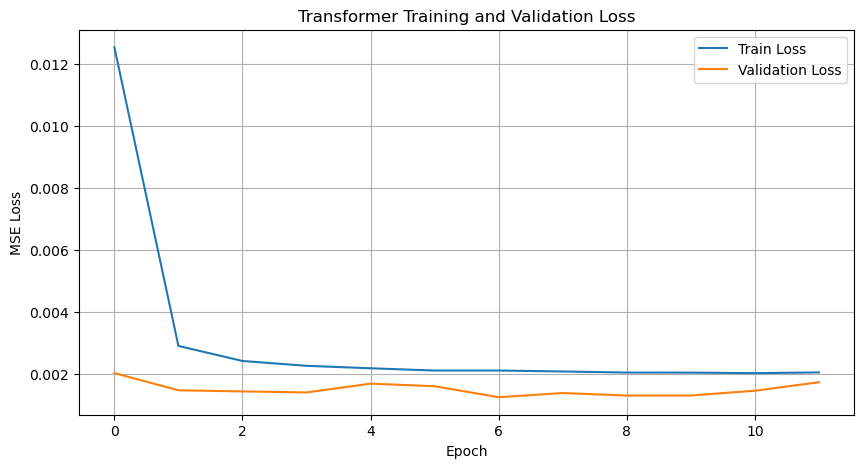

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
model.load_state_dict(
    torch.load(
        "best_transformer_model.pth",
        map_location=device
    )
)

model.eval()

y_true_scaled = []
y_pred_scaled = []

with torch.no_grad():

    for X_batch, W_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        W_batch = W_batch.to(device)

        preds = model(
            X_batch,
            W_batch
        ).cpu().numpy()

        y_pred_scaled.extend(preds)
        y_true_scaled.extend(y_batch.numpy())

y_true_scaled = np.array(y_true_scaled)
y_pred_scaled = np.array(y_pred_scaled)

y_true = y_scaler.inverse_transform(
    y_true_scaled
)

y_pred = y_scaler.inverse_transform(
    y_pred_scaled
)

mse = mean_squared_error(
    y_true,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_true,
    y_pred
)

r2 = r2_score(
    y_true,
    y_pred
)

print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Test MSE: 78.67559814453125
Test RMSE: 8.869926614382514
Test MAE: 4.74268102645874
Test R2: 0.9934472441673279


In [21]:
# =====================
# Normalized Metrics
# =====================

mse_scaled = mean_squared_error(y_true_scaled, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_true_scaled, y_pred_scaled)
r2_scaled = r2_score(y_true_scaled, y_pred_scaled)

print("=== Normalized Scale ===")
print("MSE :", mse_scaled)
print("RMSE:", rmse_scaled)
print("MAE :", mae_scaled)
print("R²  :", r2_scaled)

# =====================
# Original Scale
# =====================

y_true = y_scaler.inverse_transform(y_true_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n=== Original Scale ===")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

=== Normalized Scale ===
MSE : 0.0005894536152482033
RMSE: 0.02427866584572149
MAE : 0.012981615029275417
R²  : 0.9934472441673279

=== Original Scale ===
MSE : 78.67559814453125
RMSE: 8.869926614382514
MAE : 4.74268102645874
R²  : 0.9934472441673279


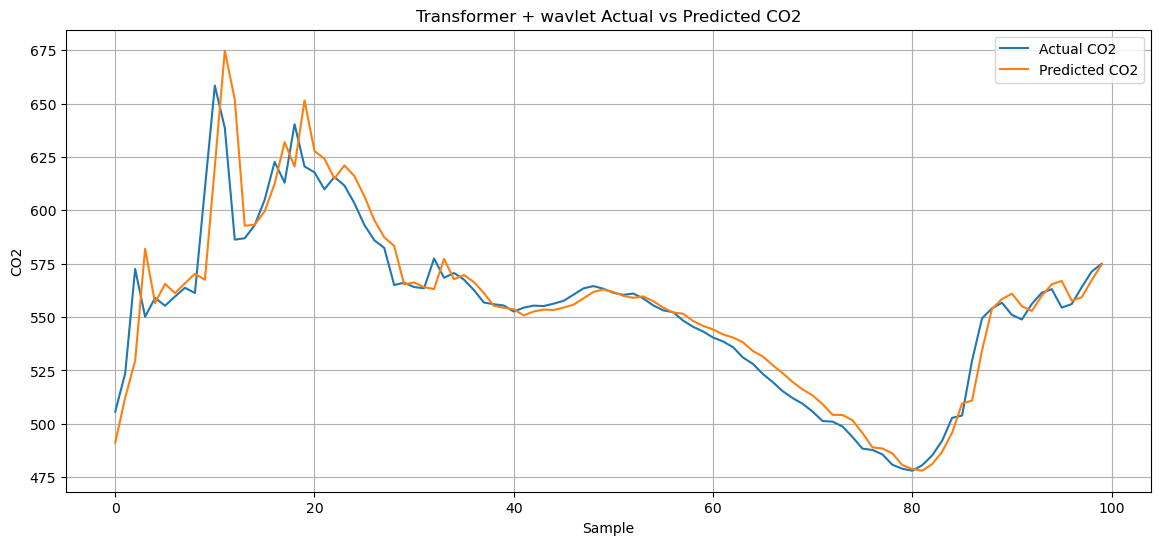

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(y_true[:100], label="Actual CO2")
plt.plot(y_pred[:100], label="Predicted CO2")
plt.xlabel("Sample")
plt.ylabel("CO2")
plt.title("Transformer + wavlet Actual vs Predicted CO2")
plt.legend()
plt.grid(True)
plt.show()